# ❤️ Myocardial Infarction (MI) Detection from 12-Lead ECG (PTB-XL Dataset)

This notebook implements an automated framework for classifying ECG signals using **classical Machine Learning** and **Deep Learning** techniques.

We compare two distinct approaches for **Binary Classification** (Normal vs. Abnormal):
1.  **Feature-Based Approach (ML):** Extracting morphological features using Median Beats and PCA, classified via Logistic Regression and Random Forest.
2.  **End-to-End Approach (DL):** Using Raw Signal data fed directly into a 1D Convolutional Neural Network (CNN).

### 🔹 Key Methodologies
* **Dataset:** PTB-XL (500 Hz), utilizing **all 12 Leads**.
* **Preprocessing:** Bandpass filtering (0.5-50 Hz) & R-Peak detection on Lead II.
* **Feature Engineering (Phase 2):**
    * **Median Beat Construction:** Robust "Territory Logic" (dynamic windowing) to handle Tachycardia/Bradycardia.
    * **Dimensionality Reduction:** Universal PCA to extract **60 standardized features** (5 components per lead).
* **Models:**
    * **Logistic Regression:** Baseline linear classifier on PCA features.
    * **Random Forest:** Non-linear ensemble classifier on PCA features.
    * **1D-CNN:** Deep learning model trained on **Raw 12-lead Time-Series** (5000 samples).

### 🔹 Goal
To evaluate if engineered morphological features (PCA) can compete with the raw signal learning capabilities of Convolutional Neural Networks for detecting cardiac abnormalities.

## Requirements

In [22]:
%pip install wfdb --no-deps

Note: you may need to restart the kernel to use updated packages.


## Import and Configuration

In [23]:
# --- Standard Library ---
import os
import json
import random
from pathlib import Path

# --- Data Manipulation & Math ---
import numpy as np
import pandas as pd
from tqdm import tqdm
import joblib

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal Processing & Domain Specific ---
import wfdb
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis

# --- Scikit-Learn (Machine Learning) ---
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# --- TensorFlow / Keras (Deep Learning) ---
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras import Sequential, backend as K
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dense, Dropout, SpatialDropout1D,
    Activation,BatchNormalization, Add, GlobalAveragePooling1D, Concatenate,
    Lambda, Reshape, UpSampling1D, Conv1DTranspose, Layer, Cropping1D
)

# --- Configuration & Constants ---
INPUT_DIR = "/kaggle/input/"
OUTPUT_DIR = "/kaggle/working/"
DATASET_PATH = os.path.join(INPUT_DIR, "ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1")
META_FILE_PTB = os.path.join(DATASET_PATH, "ptbxl_database.csv")
META_FILE_SCP = os.path.join(DATASET_PATH, "scp_statements.csv")

SEED = 42
SAMPLE_RATE = 500
TEST_SIZE = 0.2
MAX_RECORDS = 3000

CNN_EPOCHS = 50
BATCH_SIZE = 32

# Set Seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Helper Functions

In [24]:
def safe_eval_scp(scp_code):
    """
    Description: Safely converts string-formatted SCP dictionaries into Python dictionary objects.
    Input: str or dict
    Output: dict
    """
    try: return eval(scp_code) if isinstance(scp_code, str) else scp_code
    except: return {}

def ensure_len(sig, expected):
    """
    Description: Standardizes signal length by truncating or zero-padding to a fixed size.
    Note: samples = signal duration * frequency
    Input: numpy array [samples, leads] or [samples,], int
    Output: numpy array [samples, leads] or [samples,]
    """
    length = len(sig)

    # signal length is as expected
    if length == expected:
        return sig

    # signal length is more than expected
    if length > expected:
        return sig[:expected]

    # signal length is more than expected
    diff = expected - length
    if sig.ndim == 1:
        # Assume shape (time,)
        pad = np.zeros(diff)
        return np.concatenate([sig, pad])
    else: 
        # Assume shape (time, leads)
        leads = sig.shape[1]
        pad = np.zeros((diff, leads))
        return np.concatenate([sig, pad], axis=0)

def normalize_per_record(X):
    """
    Description: Performs Z-score normalization independently for each ECG record.
    Note: ecg_samples = signal duration * frequency
    Input: numpy array [data_samples, ecg_samples, ecg_leads]
    Output: numpy array [data_samples, ecg_samples, ecg_leads]
    """
    # Mean and Std along the ecg_samples dimension (axis 1)
    m = X.mean(axis=1, keepdims=True)
    s = X.std(axis=1, keepdims=True) + 1e-8
    return (X - m) / s

def print_result(res):
    """
    Description: Formats and prints classification performance metrics to the console.
    Input: dict [model, accuracy, precision, recall, f1 score]
    """
    print(f"\nModel: {res['model']}")
    print(f"Accuracy: {res['accuracy']:.2%}")
    print(f"Precision: {res['precision']:.2%}")
    print(f"Recall: {res['recall']:.2%}")
    print(f"F1 Score: {res['f1 score']:.2%}")

## Load Metadata

In [25]:
def load_metadata(max_records=MAX_RECORDS):
    """
    Description: Loads PTB-XL CSV files, applies a priority-based diagnostic hierarchy for labeling, and performs stratified sampling.
    Input: int
    Output: pandas DataFrame [ecg_id, scp_codes, label_multiclass, label_binary, filename_hr, ...]
    """
    # Load raw dataframes
    ptb_df = pd.read_csv(META_FILE_PTB)
    scp_df = pd.read_csv(META_FILE_SCP, index_col=0)

    # Convert scp_codes from string to dict
    ptb_df["scp_codes"] = ptb_df["scp_codes"].apply(safe_eval_scp)

    # Drop records without a filename
    ptb_df = ptb_df[ptb_df["filename_hr"].notna()].reset_index(drop=True)

    # --- Step 1: Build the Dictionary Map (SCP Code -> Diagnostic Class) ---
    # We only keep codes that have a valid diagnostic_class (MI, STTC, CD, HYP, NORM)
    scp_df = scp_df[scp_df["diagnostic_class"].notna()]
    diagnostic_class = scp_df["diagnostic_class"].to_dict()

    # --- Step 2: Define the Labeling Function with Hierarchy ---
    def get_label(scp_dict):
        """
        Description: Assigns a single diagnostic label to a record based on a priority hierarchy: MI > STTC > CD > HYP > NORM.
        Input: dict
        Output: int (-1 to 4)
        """
        # Get all diagnostic classes present for this patient
        classes = set()
        for scp_code in scp_dict.keys():
            if scp_code in diagnostic_class:
                classes.add(diagnostic_class[scp_code])

        # Check Priority: MI > STTC > CD > HYP > NORM
        if "MI" in classes: return 1      # MI
        if "STTC" in classes: return 2    # STTC
        if "CD" in classes: return 3      # CD
        if "HYP" in classes: return 4     # HYP
        if "NORM" in classes: return 0    # NORM

        return -1 # Unknown/Other (will be dropped)

    # --- Step 3: Apply Labels ---
    ptb_df["label_multiclass"] = ptb_df["scp_codes"].apply(get_label)

    # Drop "Other/Unknown" (-1)
    ptb_df = ptb_df[ptb_df["label_multiclass"] != -1].reset_index(drop=True)

    # Create Binary Label: 0=NORM, 1=Abnormal (MI, STTC, CD, HYP)
    ptb_df["label_binary"] = ptb_df["label_multiclass"].apply(lambda x: 0 if x == 0 else 1)

    # --- Step 4: Stratified Sampling (Optional) ---
    if max_records is not None and max_records < len(ptb_df):
        # Stratify by multiclass label to keep distribution balanced
        ptb_df, _ = train_test_split(
            ptb_df,
            train_size=max_records,
            stratify=ptb_df["label_multiclass"],
            random_state=SEED,
        )
        ptb_df = ptb_df.reset_index(drop=True)

    return ptb_df

ptb_df = load_metadata()
print("Total records used:", len(ptb_df))
print("\nMulticlass Counts (0=NORM, 1=MI, 2=STTC, 3=CD, 4=HYP):")
print(ptb_df["label_multiclass"].value_counts().sort_index())
print("\nBinary Counts (0=Normal, 1=Abnormal):")
print(ptb_df["label_binary"].value_counts())
ptb_df[["ecg_id", "scp_codes", "label_multiclass", "label_binary"]]

Total records used: 3000

Multiclass Counts (0=NORM, 1=MI, 2=STTC, 3=CD, 4=HYP):
label_multiclass
0    1272
1     768
2     547
3     338
4      75
Name: count, dtype: int64

Binary Counts (0=Normal, 1=Abnormal):
label_binary
1    1728
0    1272
Name: count, dtype: int64


,ecg_id,scp_codes,label_multiclass,label_binary
0,5181,"{'IRBBB': 100.0, 'SR': 0.0}",3,1
1,21559,"{'NORM': 100.0, 'SR': 0.0}",0,0
2,14982,"{'LVH': 100.0, 'ISC_': 100.0, 'IVCD': 100.0, '...",2,1
3,20719,"{'NORM': 80.0, 'SR': 0.0}",0,0
4,8546,"{'LAFB': 100.0, 'SR': 0.0}",3,1
...,...,...,...,...
2995,21535,"{'LVH': 50.0, 'ISC_': 100.0, 'AFIB': 0.0}",2,1
2996,9402,"{'IMI': 100.0, 'ASMI': 100.0, '1AVB': 100.0, '...",1,1
2997,17394,"{'LMI': 15.0, 'ASMI': 50.0, 'IRBBB': 100.0, 'A...",1,1
2998,18538,"{'ASMI': 100.0, 'LAFB': 100.0, 'ABQRS': 0.0, '...",1,1


## Load One Signal and Smoke Test

Showing first 1 records (12-Lead view)...


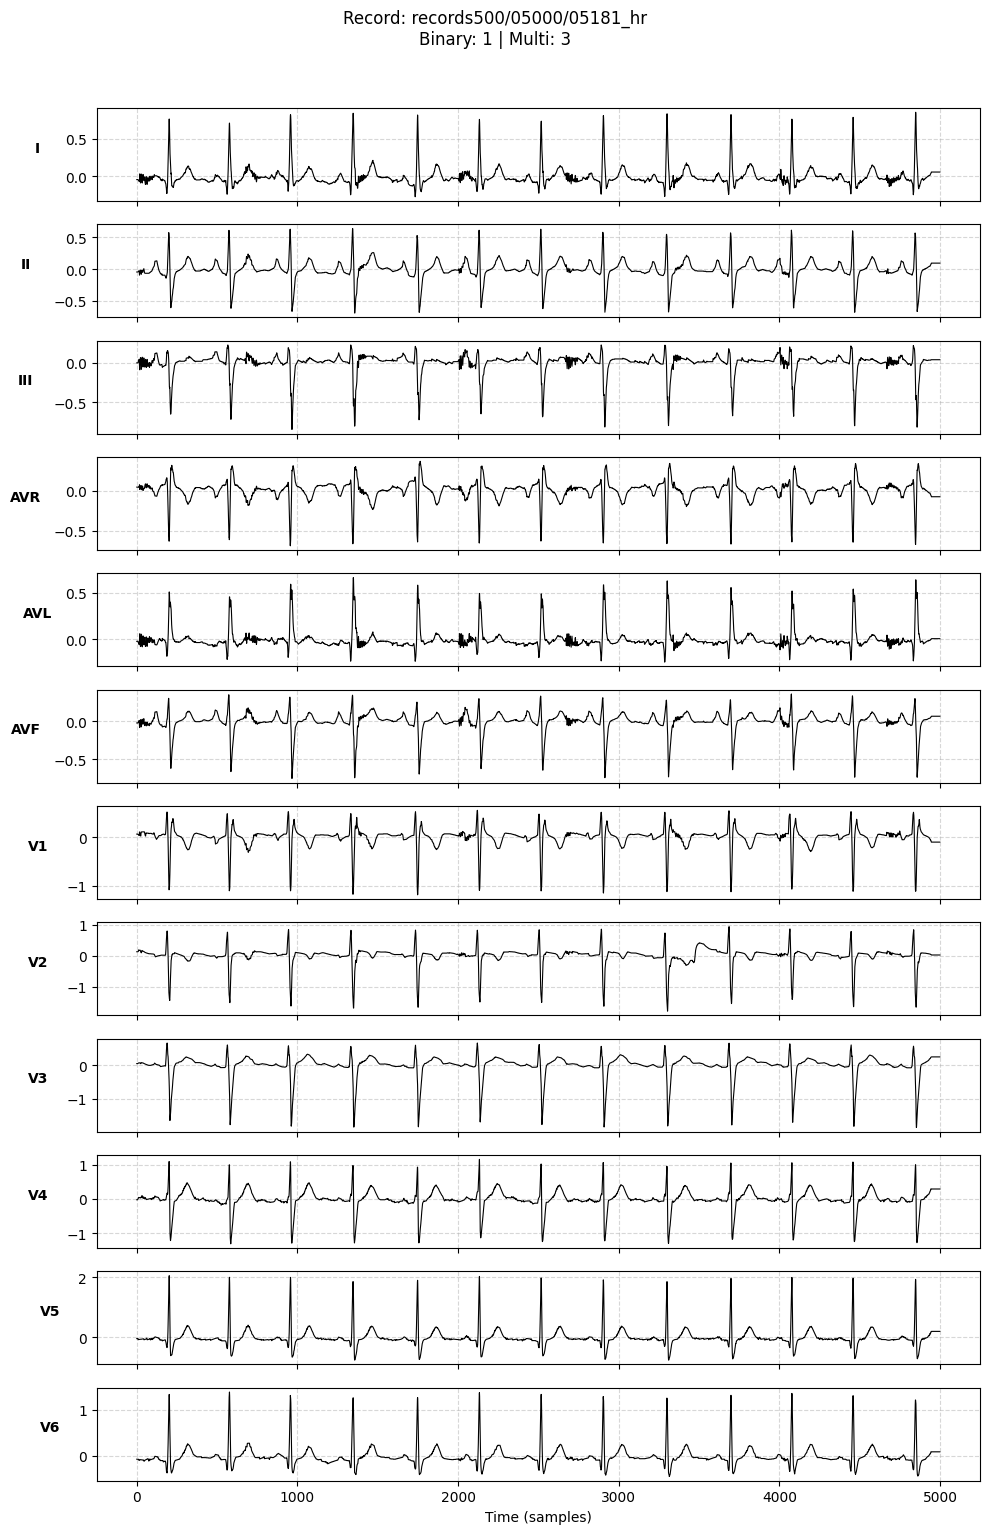

In [26]:
def load_signal_single(ecg_record):
    """
    Description: Loads a 12-lead ECG signal from the dataset using the WFDB library and converts it to float32 precision.
    Note: samples = signal duration * frequency
    Input: str
    Output: numpy array [samples, leads]
    """
    try:
        ecg_record_path = os.path.join(DATASET_PATH, ecg_record)
        signal, fields = wfdb.rdsamp(ecg_record_path)
        return signal.astype(np.float32)
    except:
        return None

def smoke_test(df, count=1):
    """
    Description: Visualizes the first N records of the provided DataFrame in a stacked 12-lead anatomical view to verify data integrity.
    Input: pandas DataFrame [filename_hr, label_binary, label_multiclass, ...], int
    """
    print(f"Showing first {count} records (12-Lead view)...")

    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    for row in df.itertuples():
        sig = load_signal_single(row.filename_hr)
        if sig is None:
            continue

        # Ensure length
        sig = ensure_len(sig, SAMPLE_RATE * 10)

        # Plot all 12 leads stacked
        fig, axes = plt.subplots(12, 1, figsize=(10, 15), sharex=True)

        for i in range(12):
            ax = axes[i]
            ax.plot(sig[:, i], color='black', linewidth=0.8)
            ax.set_ylabel(lead_names[i], rotation=0, labelpad=20, fontsize=10, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.5)
            if i < 11:
                ax.tick_params(labelbottom=False)

        plt.suptitle(f"Record: {row.filename_hr}\nBinary: {row.label_binary} | Multi: {row.label_multiclass}", y=1.02)
        plt.xlabel("Time (samples)")
        plt.tight_layout()
        plt.show()

        count -= 1
        if count == 0:
            return

smoke_test(df=ptb_df)

## Build Raw Dataset

In [28]:
def build_raw_dataset(df):
    """
    Description: Iteratively loads, standardizes, and aggregates raw 12-lead ECG signals along with their binary and multiclass labels into numpy arrays.
    Input: pandas DataFrame [filename_hr, label_binary, label_multiclass]
    Output: tuple (
                numpy array [data_samples, ecg_samples, ecg_leads], 
                numpy array [data_samples], 
                numpy array [data_samples], 
                list
            )
    """
    X, y_bin, y_multi, rec_ids = [], [], [], []

    for row in tqdm(df.itertuples(), desc="Loading ECG signals"):
        # Load the full 12-lead signal
        sig = load_signal_single(row.filename_hr)
        if sig is None:
            continue

        # Ensure length 
        sig = ensure_len(sig, SAMPLE_RATE * 10)

        X.append(sig)
        y_bin.append(row.label_binary)
        y_multi.append(row.label_multiclass)
        rec_ids.append(row.filename_hr)

    # Stack to create 3D Array: (data_samples, ecg_samples, ecg_leads)
    X = np.stack(X)
    y_bin = np.array(y_bin)
    y_multi = np.array(y_multi)

    return X, y_bin, y_multi, rec_ids

# --- Execute the Build ---
X, y_bin, y_multi, rec_ids = build_raw_dataset(ptb_df)

# --- Normalize ---
X = normalize_per_record(X)

print("\nDataset Built!")
print("X shape:", X.shape)
print("y_bin shape:", y_bin.shape)
print("y_multi shape:", y_multi.shape)

Loading ECG signals: 3000it [00:20, 144.16it/s]



Dataset Built!
X shape: (3000, 5000, 12)
y_bin shape: (3000,)
y_multi shape: (3000,)


## Feature Extraction Helper Functions 

In [11]:
WINDOW_LEN = 300
PRE_R = 100
POST_R = 200
SAFETY_MARGIN = 10

N_PCA_COMPONENTS = 5


def get_median_beats(sig):
    """
    Extracts the median beat from a 12-lead signal.
    Input: sig (5000, 12)
    Output: median_beat (12, 300) -> Transposed for PCA consistency
    """
    # 1. Detect Peaks on Lead II (Index 1)
    peaks, _ = find_peaks(sig[:, 1], distance=150, height=0.1)

    # If no peaks, return zeros (12 leads x 300 samples)
    if len(peaks) == 0:
        return np.zeros((12, WINDOW_LEN), dtype=np.float32)

    beats = []

    for i, r_curr in enumerate(peaks):
        # --- A. Define Ideal Territory ---
        ideal_start = r_curr - PRE_R
        ideal_end = r_curr + POST_R

        # --- B. Define Safety Limits ---
        if i > 0:
            limit_start = peaks[i-1] + POST_R + SAFETY_MARGIN
        else:
            limit_start = 0

        if i < len(peaks) - 1:
            limit_end = peaks[i+1] - PRE_R - SAFETY_MARGIN
        else:
            limit_end = sig.shape[0]

        # --- C. Truncate ---
        actual_start = max(ideal_start, limit_start)
        actual_end = min(ideal_end, limit_end)

        actual_start = max(0, actual_start)
        actual_end = min(sig.shape[0], actual_end)

        # --- D. The Canvas Method ---
        canvas = np.zeros((WINDOW_LEN, 12), dtype=np.float32)
        canvas_start_idx = PRE_R - (r_curr - actual_start)

        chunk = sig[actual_start:actual_end]
        chunk_len = len(chunk)

        if chunk_len == 0 or canvas_start_idx < 0 or (canvas_start_idx + chunk_len) > WINDOW_LEN:
            continue

        canvas[canvas_start_idx : canvas_start_idx + chunk_len] = chunk
        beats.append(canvas)

    # --- E. Compute Median ---
    if len(beats) == 0:
        return np.zeros((12, WINDOW_LEN), dtype=np.float32)

    beats = np.stack(beats) # Shape: (N_beats, 300, 12)
    median_beat = np.median(beats, axis=0) # Shape: (300, 12)

    # Transpose to return (12, 300)
    return median_beat.T

def train_pca_model(X):
    """
    Trains PCA on training set.
    Input: X (N, 5000, 12)
    Output: Trained PCA object
    """
    print("Preparing data for PCA training...")
    all_beats = []

    for x in tqdm(X, desc="Extracting Training Beats"):
        mb = get_median_beats(x) # Returns (12, 300)
        all_beats.append(mb)     # List of (12, 300) arrays

    # Stack: (N_patients * 12, 300)
    X_for_pca = np.vstack(all_beats)

    print(f"Training PCA on {X_for_pca.shape[0]} individual lead waveforms...")
    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(X_for_pca)

    print(f"PCA Variance Explained: {np.sum(pca.explained_variance_ratio_):.2%}")
    return pca

def extract_pca_features(X, pca_model):
    """
    Transforms signals into features.
    Input: X (N, 5000, 12)
    Output: features (N, 60)
    """
    features = []

    for x in tqdm(X, desc="Transforming Features"):
        mb = get_median_beats(x) # (12, 300)

        # Project: Input (12, 300) -> Output (12, 5)
        coeffs = pca_model.transform(mb)

        # Flatten: 12 * 5 = 60 features
        features.append(coeffs.flatten())

    return np.array(features)

## Train Test Split and Features Extraction

In [12]:
# 1. Stratified Split (Raw Data)
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X,
    y_bin,
    y_multi,
    test_size=TEST_SIZE,
    stratify=y_multi,
    random_state=SEED
)

print(f"Split Sizes: Train={len(X_train)}, Test={len(X_test)}")

# 2. Train PCA (On Training Set Only)
pca = train_pca_model(X_train)

# 3. Extract Features
print("\nExtracting features for Training Set...")
Xf_train = extract_pca_features(X_train, pca)

print("\nExtracting features for Test Set...")
Xf_test = extract_pca_features(X_test, pca)

# 4. Scale Features
scaler = StandardScaler()
Xf_train = scaler.fit_transform(Xf_train)
Xf_test = scaler.transform(Xf_test)

Split Sizes: Train=2400, Test=600
Preparing data for PCA training...


Extracting Training Beats: 100%|██████████| 2400/2400 [00:03<00:00, 743.62it/s]


Training PCA on 28800 individual lead waveforms...
PCA Variance Explained: 91.82%

Extracting features for Training Set...


Transforming Features: 100%|██████████| 2400/2400 [00:03<00:00, 612.09it/s]



Extracting features for Test Set...


Transforming Features: 100%|██████████| 600/600 [00:00<00:00, 614.74it/s]


## Features Display

In [13]:
# --- Flexible Feature Display Function ---
def show_feature_table(features, lead_idx=None):
    """
    Creates a DataFrame for the features and displays the head.
    lead_idx: Integer (0-11) to filter for a specific lead.
              If None, displays all 60 features.
    """
    # 1. Generate Column Names
    lead_names = ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    col_names = [f"{lead}_C{i+1}" for lead in lead_names for i in range(N_PCA_COMPONENTS)]

    # 2. Create Full DataFrame
    df = pd.DataFrame(features, columns=col_names)

    # 3. Filter or Show All
    if lead_idx is not None:
        if 0 <= lead_idx < 12:
            target_lead = lead_names[lead_idx]
            # Select columns containing the lead name (e.g., "II_C1", "II_C2"...)
            # We use specific slicing math: start = idx*5, end = start+5
            start_col = lead_idx * N_PCA_COMPONENTS
            end_col = start_col + N_PCA_COMPONENTS

            print(f"\n--- Features for Lead {target_lead} (Index {lead_idx}) ---")
            display(df.iloc[:, start_col:end_col].head())
        else:
            print(f"Error: Lead index must be 0-11.")
    else:
        print("\n--- All 60 Features (12 Leads x 5 Components) ---")
        display(df.head())

# --- Usage Examples ---
# Example 1: Show Lead II (Index 1) - Often the most important lead
show_feature_table(Xf_train, lead_idx=1)

# Example 2: Show All Features
# show_feature_table(Xf_train)


--- Features for Lead II (Index 1) ---


,II_C1,II_C2,II_C3,II_C4,II_C5
0,-1.029063,0.503254,0.146272,0.134433,0.648865
1,-1.065386,0.464787,0.100204,0.081199,0.330864
2,1.409641,-0.293611,-0.467515,-0.783931,-1.254880
3,-0.979498,0.364077,0.169341,0.019639,0.567272
4,-0.834783,-1.423910,0.460254,-2.085701,0.776189


## Universal Evaluator

In [14]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Calculates metrics and displays confusion matrix.
    Returns a dictionary of metrics.
    """
    print(f"\n{'='*40}")
    print(f"EVALUATION: {model_name}")
    print(f"{'='*40}")

    # 1. Calculate Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # 2. Print Report
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 20)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.show()

    # 4. Return Object
    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1 score": f1
    }


## Machine Learning Models Training

In [15]:
# Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
print("Training Logistic Regression on PCA Features...")
lr_model.fit(Xf_train, y_train_bin)

# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, random_state=SEED)
print("Training Random Forest on PCA Features...")
rf_model.fit(Xf_train, y_train_bin)

Training Logistic Regression on PCA Features...
Training Random Forest on PCA Features...


RandomForestClassifier(n_estimators=200, random_state=42)

## Machine Learning Models Evaluation


EVALUATION: Logistic Regression (PCA)
Accuracy:  0.7050
Precision: 0.7097
Recall:    0.8266
F1 Score:  0.7637
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.54      0.61       254
    Abnormal       0.71      0.83      0.76       346

    accuracy                           0.70       600
   macro avg       0.70      0.68      0.69       600
weighted avg       0.70      0.70      0.70       600



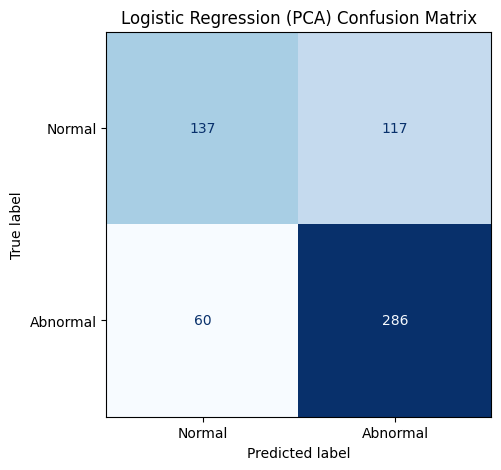


EVALUATION: Random Forest (PCA)
Accuracy:  0.7250
Precision: 0.7375
Recall:    0.8121
F1 Score:  0.7730
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.70      0.61      0.65       254
    Abnormal       0.74      0.81      0.77       346

    accuracy                           0.72       600
   macro avg       0.72      0.71      0.71       600
weighted avg       0.72      0.72      0.72       600



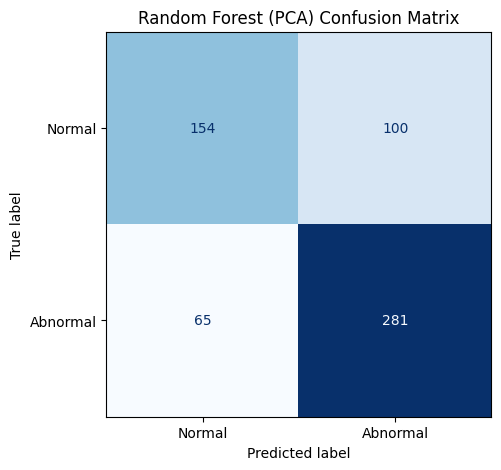

['/kaggle/working/rf_model.pkl']

In [16]:
# Train Logistic Regression Model
y_pred_lr = lr_model.predict(Xf_test)
res_lr = evaluate_model("Logistic Regression (PCA)", y_test_bin, y_pred_lr)
joblib.dump(lr_model, os.path.join(OUTPUT_DIR, 'lr_model.pkl'))

# Train Random Forest Model
y_pred_rf = rf_model.predict(Xf_test)
res_rf = evaluate_model("Random Forest (PCA)", y_test_bin, y_pred_rf)
joblib.dump(rf_model, os.path.join(OUTPUT_DIR, 'rf_model.pkl'))

## CNN Model Building and Training (Binary Classification)

In [18]:
# 1. Define CNN Architecture
def build_cnn(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # --- Block 1: The "Spike Detector" (Low-level features) ---
    model.add(Conv1D(filters=32, kernel_size=10, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=2))

    # --- Block 2: The "Wave Detector" (Mid-level features) ---
    model.add(Conv1D(filters=64, kernel_size=10, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=2))

    # --- Block 3: The "Complex Shape Detector" (High-level features) ---
    # This layer sees the relationship between P, QRS, and T
    model.add(Conv1D(filters=128, kernel_size=10, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling1D(pool_size=2))

    # --- Block 4: Optional Deep Feature Extraction ---
    model.add(Conv1D(filters=256, kernel_size=10, padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    # Global Average Pooling replaces Flatten (Reduces parameters, prevents overfitting)
    model.add(GlobalAveragePooling1D())

    # --- Classifier Head ---
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5)) # Standard dropout to force robustness
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid')) # Binary Output

    # Compile
    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 3. Build
print(f"\n{'='*40}")
print("TRAINING CNN")
print(f"{'='*40}")

cnn = build_cnn((5000, 12))

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

# 4. Train
history_cnn = cnn.fit(
    X_train, y_train_bin,
    validation_data=(X_test, y_test_bin),
    epochs=CNN_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

#5. Save
cnn.save(os.path.join(OUTPUT_DIR, 'cnn_model_raw.h5'))


TRAINING CNN


I0000 00:00:1777713424.695281      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/50


I0000 00:00:1777713431.347979     142 service.cc:152] XLA service 0x7d97e8056fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777713431.348044     142 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777713432.178288     142 cuda_dnn.cc:529] Loaded cuDNN version 91002


 7/75 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5685 - loss: 0.6790 

I0000 00:00:1777713437.571152     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7203 - loss: 0.5351 - val_accuracy: 0.5767 - val_loss: 1.2593 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8167 - loss: 0.4188 - val_accuracy: 0.7183 - val_loss: 0.5271 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8347 - loss: 0.3928 - val_accuracy: 0.7417 - val_loss: 0.5072 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8316 - loss: 0.3797 - val_accuracy: 0.6367 - val_loss: 0.6269 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8433 - loss: 0.3699 - val_accuracy: 0.8333 - val_loss: 0.3653 - learning_rate: 0.0010
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8511 - loss: 0.3542 - val_accuracy: 0.8333 - val_loss: 0.3674 - learning_rate: 0.0010
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8567 - loss: 0.3458 - val_accuracy: 0.8

##  CNN Model Evaluation (Binary Classification)


CNN EVALUATION

Generating Predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step

Final Evaluation Results:

EVALUATION: CNN (Raw)
Accuracy:  0.8350
Precision: 0.8824
Recall:    0.8237
F1 Score:  0.8520
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.78      0.85      0.81       254
    Abnormal       0.88      0.82      0.85       346

    accuracy                           0.83       600
   macro avg       0.83      0.84      0.83       600
weighted avg       0.84      0.83      0.84       600



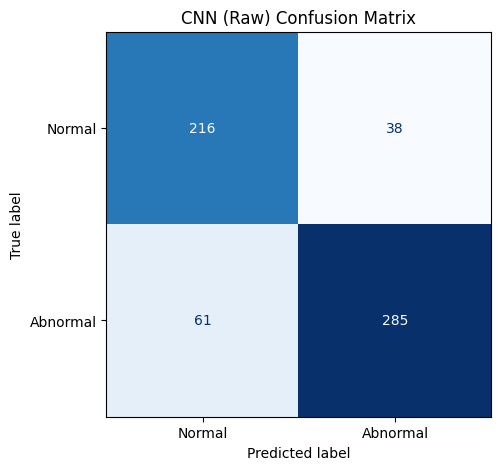

In [19]:
# Predict
print(f"\n{'='*50}")
print("CNN EVALUATION")
print(f"{'='*50}")

print("\nGenerating Predictions...")
y_pred_prob_cnn = cnn.predict(X_test)
y_pred_bin_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()

# Evaluate
print("\nFinal Evaluation Results:")
res_cnn = evaluate_model("CNN (Raw)", y_test_bin, y_pred_bin_cnn)

## AG-ResNET Model Building and Training (Binary Classification)

In [20]:
# ==============================================================================
# 1. MODEL CONFIGURATION
# ==============================================================================
INPUT_SHAPE = (5000, 12)
NUM_CLASSES = 1
POOL_SIZE = 2
NUM_BLOCKS = 4
FILTERS_START = 64

LEARNING_RATE = 0.0005 
BATCH_SIZE = 16
EPOCHS = 50

IDX_SEPTAL = [6, 7]
IDX_ANTERIOR = [8, 9]
IDX_LATERAL = [0, 4, 10, 11]
IDX_INFERIOR = [1, 2, 5]
IDX_POSTERIOR = [3]

# ==============================================================================
# 2. HELPER BLOCKS (VAE CLASSES REMOVED)
# ==============================================================================

def residual_block(x, filters, kernel_size=7, stride=1):
    """Creates a standard Residual Block."""

    shortcut = x

    # Path A
    x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('swish')(x)
    x = SpatialDropout1D(0.2)(x)

    x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Path B
    if x.shape[-1] != shortcut.shape[-1] or stride != 1:
        shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('swish')(x)
    return x

# ==============================================================================
# 3. ARCHITECTURE BUILDER (PURE CLASSIFIER)
# ==============================================================================

def build_ag_resnet(input_shape=INPUT_SHAPE):

    # --- BLOCK 1: INPUT & TRIAGE ---
    input_layer = Input(shape=input_shape, name="ecg_input")

    septal = Lambda(lambda x: tf.gather(x, IDX_SEPTAL, axis=2), name="Septal")(input_layer)
    anterior = Lambda(lambda x: tf.gather(x, IDX_ANTERIOR, axis=2), name="Anterior")(input_layer)
    lateral = Lambda(lambda x: tf.gather(x, IDX_LATERAL, axis=2), name="Lateral")(input_layer)
    inferior = Lambda(lambda x: tf.gather(x, IDX_INFERIOR, axis=2), name="Inferior")(input_layer)
    posterior = Lambda(lambda x: tf.gather(x, IDX_POSTERIOR, axis=2), name="Posterior")(input_layer)

    # --- BLOCK 2: ENCODER ---
    branches = []
    for region_name, branch_in in zip(["Sept", "Ant", "Lat", "Inf", "Post"],
                                      [septal, anterior, lateral, inferior, posterior]):

        # Initial Feature Extraction
        x = Conv1D(FILTERS_START, 7, strides=POOL_SIZE, padding='same', name=f"{region_name}_Conv1")(branch_in)
        x = BatchNormalization()(x)
        x = Activation('swish')(x)

        # Dynamic Residual Stacking
        current_filters = FILTERS_START * 2
        for i in range(NUM_BLOCKS):
            x = residual_block(x, current_filters, stride=POOL_SIZE)
            current_filters *= 2

        x = GlobalAveragePooling1D(name=f"{region_name}_GlobalPool")(x)
        branches.append(x)

    # --- BLOCK 3: FUSION (No VAE Sampling) ---
    merged = Concatenate(name="Anatomical_Fusion")(branches)

    # --- BLOCK 4: CLASSIFICATION HEAD ---
    c = BatchNormalization()(merged)
    c = Dense(128, activation='swish')(c)
    c = Dropout(0.3)(c)
    
    classification_output = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)

    # --- BLOCK 5: COMPILATION (Pure Classification) ---
    model = Model(inputs=input_layer, outputs=classification_output, name="AG_ResNet")

    # Added clipnorm=1.0 to prevent gradient explosions
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=1.0), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# ==============================================================================
# 4. EXECUTION PIPELINE (SIMPLIFIED)
# ==============================================================================

print(f"{'='*50}")
print(f"AG-ResNet TRAINING (PURE CLASSIFIER)")
print(f"Input: {INPUT_SHAPE}")
print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
print(f"{'='*50}")

# Build
model_ag_resnet = build_ag_resnet()

# Train
callbacks_ag_resnet = [
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, 
        patience=5, min_lr=1e-5, verbose=1
    ),
    EarlyStopping(
        monitor='val_loss', patience=12, 
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(OUTPUT_DIR, "best_ag_resnet.keras"),
        monitor='val_accuracy', save_best_only=True, verbose=1)
]


weight_healthy = 1.0
weight_sick = 3.0

print("\nStarting Training...")
history_ag_resnet = model_ag_resnet.fit(
    x=X_train,
    y=y_train_bin,
    validation_data=(X_test, y_test_bin),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ag_resnet,
    class_weight={0: weight_healthy, 1: weight_sick},
    verbose=1
)

AG-ResNet TRAINING (PURE CLASSIFIER)
Input: (5000, 12)
Structure: 4 Blocks | Start Filters: 64

Starting Training...
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.6540 - loss: 2.6941
Epoch 1: val_accuracy improved from -inf to 0.57667, saving model to /kaggle/working/best_ag_resnet.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 167s 448ms/step - accuracy: 0.6542 - loss: 2.6911 - val_accuracy: 0.5767 - val_loss: 5.9395 - learning_rate: 5.0000e-04
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.7034 - loss: 1.6129
Epoch 2: val_accuracy improved from 0.57667 to 0.62000, saving model to /kaggle/working/best_ag_resnet.keras
150/150 ━━━━━━━━━━━━━━━━━━━━ 58s 386ms/step - accuracy: 0.7034 - loss: 1.6131 - val_accuracy: 0.6200 - val_loss: 5.5346 - learning_rate: 5.0000e-04
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.7287 - loss: 1.4048
Epoch 3: val_accuracy improved from 0.62000 to 0.71667, saving model to /kaggle/working/best_ag_resnet.kera

## AG-ResNET Model Evaluation (Binary Classification)


AG-ResNet EVALUATION

Generating Predictions...
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 500ms/step

Final Evaluation Results:

EVALUATION: AG-ResNet (RAW)
Accuracy:  0.8383
Precision: 0.8411
Recall:    0.8873
F1 Score:  0.8636
--------------------
Classification Report:
              precision    recall  f1-score   support

      Normal       0.83      0.77      0.80       254
    Abnormal       0.84      0.89      0.86       346

    accuracy                           0.84       600
   macro avg       0.84      0.83      0.83       600
weighted avg       0.84      0.84      0.84       600



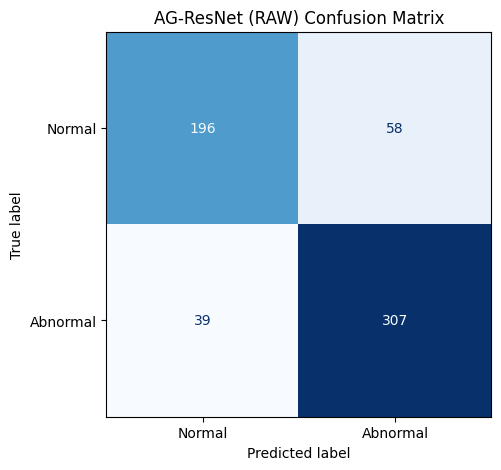

In [21]:
# Predict
print(f"\n{'='*50}")
print("AG-ResNet EVALUATION")
print(f"{'='*50}")

print("\nGenerating Predictions...")
y_pred_prob_ag_resnet = model_ag_resnet.predict(X_test).flatten()
y_pred_bin_ag_resnet = (y_pred_prob_ag_resnet > 0.5).astype(int)

# Evaluate
print("\nFinal Evaluation Results:")
res_ag_resnet = evaluate_model("AG-ResNet (RAW)", y_test_bin, y_pred_bin_ag_resnet)

## AG-ResVAE Model Building and Training (Binary Classification) OLD

In [ ]:
# # ==============================================================================
# # 1. MODEL CONFIGURATION
# # ==============================================================================
# INPUT_SHAPE = (5000, 12)
# NUM_CLASSES = 1
# POOL_SIZE = 2
# NUM_BLOCKS = 4
# FILTERS_START = 64
# LATENT_DIM = 128

# LEARNING_RATE = 3e-4
# BATCH_SIZE = 16
# EPOCHS = 50

# WEIGHT_CLASSIFICATION = 1.0
# WEIGHT_RECONSTRUCTION = 0.5
# KL_LOSS_WEIGHT = 0.01

# IDX_SEPTAL = [6, 7]
# IDX_ANTERIOR = [8, 9]
# IDX_LATERAL = [0, 4, 10, 11]
# IDX_INFERIOR = [1, 2, 5]
# IDX_POSTERIOR = [3]

# # ==============================================================================
# # 2. HELPER BLOCKS
# # ==============================================================================

# def residual_block(x, filters, kernel_size=7, stride=1):
#     """Creates a Residual Block."""

#     shortcut = x

#     # Path A
#     x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
#     x = BatchNormalization()(x)
#     x = Activation('swish')(x)
#     x = SpatialDropout1D(0.3)(x)

#     x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
#     x = BatchNormalization()(x)

#     # Path B
#     if x.shape[-1] != shortcut.shape[-1] or stride != 1:
#         shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
#         shortcut = BatchNormalization()(shortcut)

#     x = Add()([x, shortcut])
#     x = Activation('swish')(x)
#     return x

# class Sampling(Layer):
#     """VAE Sampling Layer."""
#     def call(self, inputs):
#         z_mean, z_log_var = inputs
#         batch = tf.shape(z_mean)[0]
#         dim = tf.shape(z_mean)[1]
#         epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
#         return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# class KLLossLayer(Layer):
#     """Calculates KL Divergence Loss safely."""
#     def call(self, inputs):
#         z_mean, z_log_var = inputs
#         kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
#         self.add_loss(kl_loss * KL_LOSS_WEIGHT)
#         return inputs

# # ==============================================================================
# # 3. ARCHITECTURE BUILDER
# # ==============================================================================

# def build_ag_resvae(input_shape=INPUT_SHAPE, latent_dim=LATENT_DIM):

#     # --- BLOCK 1: INPUT & TRIAGE ---
#     input_layer = Input(shape=input_shape, name="ecg_input")

#     septal = Lambda(lambda x: tf.gather(x, IDX_SEPTAL, axis=2), name="Septal")(input_layer)
#     anterior = Lambda(lambda x: tf.gather(x, IDX_ANTERIOR, axis=2), name="Anterior")(input_layer)
#     lateral = Lambda(lambda x: tf.gather(x, IDX_LATERAL, axis=2), name="Lateral")(input_layer)
#     inferior = Lambda(lambda x: tf.gather(x, IDX_INFERIOR, axis=2), name="Inferior")(input_layer)
#     posterior = Lambda(lambda x: tf.gather(x, IDX_POSTERIOR, axis=2), name="Posterior")(input_layer)

#     # --- BLOCK 2: ENCODER ---
#     branches = []
#     for region_name, branch_in in zip(["Sept", "Ant", "Lat", "Inf", "Post"],
#                                       [septal, anterior, lateral, inferior, posterior]):

#         # Initial Feature Extraction
#         x = Conv1D(FILTERS_START, 7, strides=POOL_SIZE, padding='same', name=f"{region_name}_Conv1")(branch_in)
#         x = BatchNormalization()(x)
#         x = Activation('swish')(x)

#         # Dynamic Residual Stacking
#         current_filters = FILTERS_START * 2
#         for i in range(NUM_BLOCKS):
#             x = residual_block(x, current_filters, stride=POOL_SIZE)
#             current_filters *= 2

#         x = GlobalAveragePooling1D(name=f"{region_name}_GlobalPool")(x)
#         branches.append(x)

#     # --- BLOCK 3: BOTTLENECK (Latent Vector creation) ---
#     merged = Concatenate(name="Anatomical_Fusion")(branches)

#     z_mean = Dense(latent_dim, name="z_mean")(merged)
#     z_log_var = Dense(latent_dim, name="z_log_var")(merged)
#     _ = KLLossLayer()([z_mean, z_log_var])
#     z = Sampling(name="z_sampling")([z_mean, z_log_var])

#     # --- BLOCK 4: HEAD A (Diagnosis using Latent Vector) ---
#     c = Dense(128, activation='swish')(z)
#     c = Dropout(0.5)(c)
#     classification_output = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)

#     # --- BLOCK 5: HEAD B (Reconstruction using Latent Vector) ---
#     # Calculate Expected Bottleneck Size (Rounding UP)
#     total_pools = 1 + NUM_BLOCKS
#     downsample_factor = POOL_SIZE ** total_pools
#     bottleneck_len = int(np.ceil(input_shape[0] / downsample_factor))

#     # Expand Latent Vector (z)
#     d = Dense(bottleneck_len * latent_dim, activation="swish")(z)
#     d = Reshape((bottleneck_len, latent_dim))(d)

#     # Upsample (Reverse Loop)
#     filters_reverse = [2* FILTERS_START * (2**i) for i in range(NUM_BLOCKS)]
#     filters_reverse = filters_reverse[::-1]

#     for f in filters_reverse:
#         d = Conv1DTranspose(f, 7, strides=POOL_SIZE, padding='same', activation='swish')(d)

#     d = Conv1DTranspose(FILTERS_START, 7, strides=POOL_SIZE, padding='same', activation='swish')(d)

#     # SAFETY CROP
#     current_len = bottleneck_len * downsample_factor
#     crop_amount = current_len - input_shape[0]

#     if crop_amount > 0:
#         d = Cropping1D(cropping=(0, crop_amount), name="Safety_Crop")(d)

#     reconstruction_output = Conv1D(input_shape[1], 7, padding='same', activation='linear', name="reconstruction")(d)

#     # --- BLOCK 6: COMPILATION ---
#     model = Model(inputs=input_layer, outputs=[classification_output, reconstruction_output], name="AG_ResVAE")

#     model.compile(
#         optimizer=Adam(learning_rate=LEARNING_RATE),
#         loss={
#             "classification": "binary_crossentropy",
#             "reconstruction": "mse"
#         },
#         loss_weights={
#             "classification": WEIGHT_CLASSIFICATION,
#             "reconstruction": WEIGHT_RECONSTRUCTION
#         },
#         metrics={"classification": "accuracy"}
#     )

#     return model

# # ==============================================================================
# # 4. EXECUTION PIPELINE
# # ==============================================================================

# print(f"{'='*50}")
# print(f"AG-ResVAE TRAINING (OPTIMIZED)")
# print(f"Input: {INPUT_SHAPE} | Latent Dim: {LATENT_DIM}")
# print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
# print(f"{'='*50}")

# # Build
# model_ag_resvae = build_ag_resvae()

# # Train
# callbacks_ag_resvae = [
#     ReduceLROnPlateau(
#         monitor='val_classification_loss', factor=0.1, 
#         patience=5, min_lr=1e-5, verbose=1, mode='min'
#     ),
#     EarlyStopping(
#         monitor='val_classification_loss', patience=12, 
#         restore_best_weights=True, verbose=1, mode='min'
#     ),
#     ModelCheckpoint(
#         os.path.join(OUTPUT_DIR, "best_ag_resvae.keras"), 
#         monitor='val_classification_accuracy', save_best_only=True, 
#         verbose=1, mode='max'
#     )
# ]

# print("\nStarting Training...")
# history_ag_resvae = model_ag_resvae.fit(
#     x=X_train,
#     y={
#         "classification": y_train_bin,
#         "reconstruction": X_train
#     },
#     validation_data=(
#         X_test,
#         {"classification": y_test_bin, "reconstruction": X_test}
#     ),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks_ag_resvae,
#     verbose=1
# )

## AG-ResVAE Model Building and Training (Binary Classification) NEW

In [ ]:
# # ==============================================================================
# # 1. MODEL CONFIGURATION
# # ==============================================================================
# INPUT_SHAPE = (5000, 12)
# NUM_CLASSES = 1
# POOL_SIZE = 2
# NUM_BLOCKS = 4
# FILTERS_START = 64
# LATENT_DIM = 128

# LEARNING_RATE = 0.001
# BATCH_SIZE = 16
# EPOCHS = 50

# WEIGHT_CLASSIFICATION = 1.0
# WEIGHT_RECONSTRUCTION = 0.5
# KL_LOSS_WEIGHT = 0.01

# IDX_SEPTAL = [6, 7]
# IDX_ANTERIOR = [8, 9]
# IDX_LATERAL = [0, 4, 10, 11]
# IDX_INFERIOR = [1, 2, 5]
# IDX_POSTERIOR = [3]

# # ==============================================================================
# # 2. HELPER BLOCKS
# # ==============================================================================

# def residual_block(x, filters, kernel_size=7, stride=1):
#     """Creates a Residual Block."""

#     shortcut = x

#     # Path A
#     x = Conv1D(filters, kernel_size, strides=stride, padding='same')(x)
#     x = BatchNormalization()(x)
#     x = Activation('swish')(x)
#     x = SpatialDropout1D(0.3)(x)

#     x = Conv1D(filters, kernel_size, strides=1, padding='same')(x)
#     x = BatchNormalization()(x)

#     # Path B
#     if x.shape[-1] != shortcut.shape[-1] or stride != 1:
#         shortcut = Conv1D(filters, 1, strides=stride, padding='same')(shortcut)
#         shortcut = BatchNormalization()(shortcut)

#     x = Add()([x, shortcut])
#     x = Activation('swish')(x)
#     return x

# class Sampling(Layer):
#     """VAE Sampling Layer."""
#     def call(self, inputs):
#         z_mean, z_log_var = inputs
#         batch = tf.shape(z_mean)[0]
#         dim = tf.shape(z_mean)[1]
#         epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
#         return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# class KLLossLayer(Layer):
#     """Calculates KL Divergence Loss safely."""
#     def call(self, inputs):
#         z_mean, z_log_var = inputs
#         kl_loss = -0.5 * tf.reduce_mean(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
#         self.add_loss(kl_loss * KL_LOSS_WEIGHT)
#         return inputs

# # ==============================================================================
# # 3. ARCHITECTURE BUILDER
# # ==============================================================================

# def build_ag_resvae(input_shape=INPUT_SHAPE, latent_dim=LATENT_DIM):

#     # --- BLOCK 1: INPUT & TRIAGE ---
#     input_layer = Input(shape=input_shape, name="ecg_input")

#     septal = Lambda(lambda x: tf.gather(x, IDX_SEPTAL, axis=2), name="Septal")(input_layer)
#     anterior = Lambda(lambda x: tf.gather(x, IDX_ANTERIOR, axis=2), name="Anterior")(input_layer)
#     lateral = Lambda(lambda x: tf.gather(x, IDX_LATERAL, axis=2), name="Lateral")(input_layer)
#     inferior = Lambda(lambda x: tf.gather(x, IDX_INFERIOR, axis=2), name="Inferior")(input_layer)
#     posterior = Lambda(lambda x: tf.gather(x, IDX_POSTERIOR, axis=2), name="Posterior")(input_layer)

#     # --- BLOCK 2: ENCODER ---
#     branches = []
#     for region_name, branch_in in zip(["Sept", "Ant", "Lat", "Inf", "Post"],
#                                       [septal, anterior, lateral, inferior, posterior]):

#         # Initial Feature Extraction
#         x = Conv1D(FILTERS_START, 7, strides=POOL_SIZE, padding='same', name=f"{region_name}_Conv1")(branch_in)
#         x = BatchNormalization()(x)
#         x = Activation('swish')(x)

#         # Dynamic Residual Stacking
#         current_filters = FILTERS_START * 2
#         for i in range(NUM_BLOCKS):
#             x = residual_block(x, current_filters, stride=POOL_SIZE)
#             current_filters *= 2

#         x = GlobalAveragePooling1D(name=f"{region_name}_GlobalPool")(x)
#         branches.append(x)

#     # --- BLOCK 3: BOTTLENECK (Latent Vector creation) ---
#     merged = Concatenate(name="Anatomical_Fusion")(branches)

#     z_mean = Dense(latent_dim, name="z_mean")(merged)
#     z_log_var = Dense(latent_dim, name="z_log_var")(merged)
#     _ = KLLossLayer()([z_mean, z_log_var])
#     z = Sampling(name="z_sampling")([z_mean, z_log_var])

#     # --- BLOCK 4: HEAD A (Diagnosis) ---
#     c = Dense(256, activation='swish', kernel_initializer='he_normal')(z)
#     c = BatchNormalization()(c)
#     c = Dropout(0.4)(c)

#     c = Dense(128, activation='swish', kernel_initializer='he_normal')(z)
#     c = BatchNormalization()(c)
#     c = Dropout(0.4)(c)

#     classification_output = Dense(NUM_CLASSES, activation='sigmoid', name="classification")(c)

#     # --- BLOCK 5: HEAD B (Reconstruction using Latent Vector) ---
#     # Calculate Expected Bottleneck Size (Rounding UP)
#     total_pools = 1 + NUM_BLOCKS
#     downsample_factor = POOL_SIZE ** total_pools
#     bottleneck_len = int(np.ceil(input_shape[0] / downsample_factor))

#     # Expand Latent Vector (z)
#     d = Dense(bottleneck_len * latent_dim, activation="swish")(z)
#     d = Reshape((bottleneck_len, latent_dim))(d)

#     # Upsample (Reverse Loop)
#     filters_reverse = [2* FILTERS_START * (2**i) for i in range(NUM_BLOCKS)]
#     filters_reverse = filters_reverse[::-1]

#     for f in filters_reverse:
#         d = Conv1DTranspose(f, 7, strides=POOL_SIZE, padding='same', activation='swish')(d)

#     d = Conv1DTranspose(FILTERS_START, 7, strides=POOL_SIZE, padding='same', activation='swish')(d)

#     # SAFETY CROP
#     current_len = bottleneck_len * downsample_factor
#     crop_amount = current_len - input_shape[0]

#     if crop_amount > 0:
#         d = Cropping1D(cropping=(0, crop_amount), name="Safety_Crop")(d)

#     reconstruction_output = Conv1D(input_shape[1], 7, padding='same', activation='linear', name="reconstruction")(d)

#     # --- BLOCK 6: COMPILATION ---
#     model = Model(inputs=input_layer, outputs=[classification_output, reconstruction_output], name="AG_ResVAE")

#     model.compile(
#         optimizer=Adam(learning_rate=LEARNING_RATE),
#         loss={
#             "classification": "binary_crossentropy",
#             "reconstruction": "mse"
#         },
#         loss_weights={
#             "classification": WEIGHT_CLASSIFICATION,
#             "reconstruction": WEIGHT_RECONSTRUCTION
#         },
#         metrics={"classification": "accuracy"}
#     )

#     return model

# # ==============================================================================
# # 4. EXECUTION PIPELINE
# # ==============================================================================

# print(f"{'='*50}")
# print(f"AG-ResVAE TRAINING (OPTIMIZED)")
# print(f"Input: {INPUT_SHAPE} | Latent Dim: {LATENT_DIM}")
# print(f"Structure: {NUM_BLOCKS} Blocks | Start Filters: {FILTERS_START}")
# print(f"{'='*50}")

# # Build
# model_ag_resvae = build_ag_resvae()

# # Train
# callbacks_ag_resvae = [
#     ReduceLROnPlateau(
#         monitor='val_classification_loss', factor=0.1, 
#         patience=5, min_lr=1e-5, verbose=1, mode='min'
#     ),
#     EarlyStopping(
#         monitor='val_classification_loss', patience=12, 
#         restore_best_weights=True, verbose=1, mode='min'
#     ),
#     ModelCheckpoint(
#         os.path.join(OUTPUT_DIR, "best_ag_resvae.keras"), 
#         monitor='val_classification_accuracy', save_best_only=True, 
#         verbose=1, mode='max'
#     )
# ]

# # sample_weights_array = np.ones(shape=(len(y_train_bin),))
# # sample_weights_array[y_train_bin == 1] = 3.0
# # sample_weights_recon = np.ones(shape=(len(y_train_bin),))

# print("\nStarting Training...")
# history_ag = model_ag_resvae.fit(
#     x=X_train,
#     y={
#         "classification": y_train_bin,
#         "reconstruction": X_train
#     },
#     validation_data=(
#         X_test,
#         {"classification": y_test_bin, "reconstruction": X_test}
#     ),
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=callbacks_ag_resvae,
#     # sample_weight=[sample_weights_array, sample_weights_recon],
#     verbose=1
# )

# # history_ag = model_ag_resvae.fit(
# #     x=X_train,
# #     y=[y_train_bin, X_train],
# #     validation_data=(X_test, [y_test_bin, X_test]),
# #     epochs=EPOCHS,
# #     batch_size=BATCH_SIZE,
# #     callbacks=callbacks_ag_resvae,
# #     sample_weight=[sample_weights_array, None], # <-- LIST
# #     verbose=1
# # )

## AG-ResVAE Model Evaluation (Binary Classification)

In [ ]:
# # Predict
# print(f"\n{'='*50}")
# print("AG-ResVAE EVALUATION")
# print(f"{'='*50}")

# print("\nGenerating Predictions...")
# all_preds = model_ag_resvae.predict(X_test)
# y_pred_prob_ag_resvae = all_preds[0]
# y_pred_bin_ag_resvae = (y_pred_prob_ag_resvae > 0.5).astype(int).flatten()

# # Evaluate
# print("\nFinal Evaluation Results:")
# res_ag_resvae = evaluate_model("AG-ResVAE (RAW)", y_test_bin, y_pred_bin_ag_resvae)

## Final Result Of All Models

In [ ]:
# --- Standard Imports for Loading ---
import os
import joblib
from keras.models import load_model

print(f"{'='*50}")
print("FINAL PIPELINE: LOADING MODELS & PREDICTING")
print(f"{'='*50}\n")

# ==========================================
# 1. Load Machine Learning Models (Scikit-Learn)
# ==========================================

print("Loading ML Models...")
lr_loaded = joblib.load(os.path.join(OUTPUT_DIR, 'lr_model.pkl'))
rf_loaded = joblib.load(os.path.join(OUTPUT_DIR, 'rf_model.pkl'))

# ==========================================
# 2. Load Deep Learning Models (Keras)
# ==========================================

print("Loading DL Models...")
# Custom layer 'Sampling' and 'KLLossLayer' need to be passed for AG-ResVAE
cnn_loaded = load_model(os.path.join(OUTPUT_DIR, 'cnn_model_raw.h5'))
ag_resnet_loaded = load_model(os.path.join(OUTPUT_DIR, 'best_ag_resnet.keras'))
# ag_resvae_loaded = load_model(
#     os.path.join(OUTPUT_DIR, 'best_ag_resvae.keras'),
#     custom_objects={'Sampling': Sampling, 'KLLossLayer': KLLossLayer}
# )

print("All models loaded successfully!\n")

# ==========================================
# 3. Generate Predictions on Test Data
# ==========================================

# ML Predictions (using PCA features)
y_pred_bin_lr = lr_loaded.predict(Xf_test)
y_pred_bin_rf = rf_loaded.predict(Xf_test)

# DL Predictions (using Raw signals)
y_pred_prob_cnn = cnn_loaded.predict(X_test, verbose=0)
y_pred_bin_cnn = (y_pred_prob_cnn > 0.5).astype(int).flatten()

y_pred_prob_ag_resnet = ag_resnet_loaded.predict(X_test, verbose=0)
y_pred_bin_ag_resnet = (y_pred_prob_ag_resnet > 0.5).astype(int).flatten()

# ag_resvae_preds = ag_resvae_loaded.predict(X_test, verbose=0)
# y_pred_prob_ag_resvae = ag_resvae_preds[0]
# y_pred_bin_ag_resvae = (y_pred_prob_ag_resvae > 0.5).astype(int).flatten()

# ==========================================
# 4. Final Evaluation
# ==========================================

print("\n--- Final Test Set Evaluations ---")
final_lr = evaluate_model("Loaded Logistic Regression", y_test_bin, y_pred_bin_lr)
final_rf = evaluate_model("Loaded Random Forest", y_test_bin, y_pred_bin_rf)
final_cnn = evaluate_model("Loaded CNN", y_test_bin, y_pred_bin_cnn)
final_ag_resnet = evaluate_model("Loaded AG-ResNET", y_test_bin, y_pred_bin_ag_resnet)
# final_ag_resvae = evaluate_model("Loaded AG-ResVAE", y_test_bin, y_pred_bin_ag_resvae)

# Consolidate results into a final DataFrame
final_results_df = pd.DataFrame([final_lr, final_rf, final_cnn, final_ag_resnet])
display(final_results_df.style.format({
    'accuracy': '{:.2%}',
    'precision': '{:.2%}',
    'recall': '{:.2%}',
    'f1 score': '{:.2%}'
}))

# 📌 Conclusion

We trained and compared **three models** for MI detection:

### ✔ Logistic Regression (very fast, uses simple features)  
### ✔ Random Forest (better than LR in many cases)  
### ✔ 1D CNN (uses raw ECG, learns automatically)

Evaluation metrics included:
- Accuracy  
- Precision  
- Recall  
- F1  
- Confusion Matrix  